<a href="https://colab.research.google.com/github/juanpajedrez/pytorch_learning/blob/main/08_pytorch_paper_replicating_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08. PyTorch Paper Replicating Exercises

Welcome to the 08. PyTorch Paper Replicating exercises.

Your objective is to write code to satisify each of the exercises below.

Some starter code has been provided to make sure you have all the resources you need.

> **Note:** There may be more than one solution to each of the exercises.

## Resources

1. These exercises/solutions are based on [section 08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/tjpW_BY8y3g) (but try the exercises yourself first!).
3. See [all solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/).

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")


[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/nightly/cu113
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 15.57 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
print(torch.__version__)

2.10.0+cu128


### Get data

Want to download the data we've been using in PyTorch Paper Replicating: https://www.learnpytorch.io/08_pytorch_paper_replicating/#1-get-data

In [5]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [6]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [7]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [8]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7d0279d5dca0>,
 ['pizza', 'steak', 'sushi'])

In [9]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

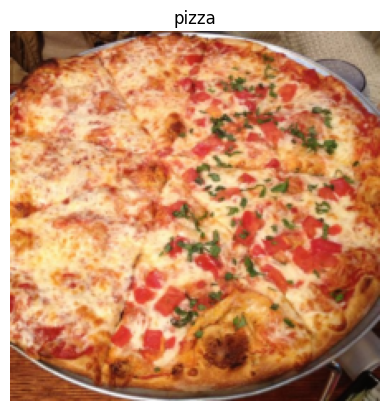

In [10]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## 1. Replicate the ViT architecture we created with in-built [PyTorch transformer layers](https://pytorch.org/docs/stable/nn.html#transformer-layers).

* You'll want to look into replacing our `TransformerEncoderBlock()` class with [`torch.nn.TransformerEncoderLayer()`](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html#torch.nn.TransformerEncoderLayer) (these contain the same layers as our custom blocks).
* You can stack `torch.nn.TransformerEncoderLayer()`'s on top of each other with [`torch.nn.TransformerEncoder()`](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html#torch.nn.TransformerEncoder).

Need:
1. `PatchEmbedding` (turn images into embedded patches).
2. Transformer Encoder layer (this is comprised of alternating MSA and MLP blocks).
3. Stack multiple transformer encoder layers on top of each other.
4. MLP head.
5. Put it all together to create ViT

### 1. Make PatchEmbedding Layer

In [11]:
#1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
  """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
  """

  # 2. Initialize the class with appropiate variables
  def __init__(self,
               in_channels:int = 3,
               patch_size:int = 16,
               embedding_dim:int= 768):
      super().__init__()

      # 3. Create a layer to turn an image into patches
      self.patcher = nn.Conv2d(in_channels = in_channels,
                               out_channels = embedding_dim,
                               kernel_size=patch_size,
                               stride = patch_size,
                               padding = 0)

      # 4. Create a layer to flatten the patch feature maps into a single dimension
      self.flatten = nn.Flatten(start_dim=2, # Only flatten the feature map dimensions into a single vector
                                end_dim=3)

      # To set it up so it can divide
      self.patch_size = patch_size

  # 5. Define the forward method
  def forward(self, x):
    # Create assertion to check that inputs are the correct shape
    image_resolution = x.shape[-1]
    assert image_resolution % self.patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"

    # Perform the forward pass
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)

    # 6. Make sure the output shape has the right order
    return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]

### 2. Transformer Encoder Layer

Can build a transformer Encoder Layer with:
https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html

In [12]:
rand_image_tensor = torch.rand(32, 3, 224, 224) # (batch_size, colour_channels, height, width)
rand_image_tensor.shape

torch.Size([32, 3, 224, 224])

In [13]:
patch_embedding = PatchEmbedding()
patch_embedding_output = patch_embedding(rand_image_tensor)
print(f"Input shape: {rand_image_tensor.shape}")
print(f"Output shape: {patch_embedding_output.shape}")

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 196, 768])


In [14]:
transformer_encoder_layer = nn.TransformerEncoderLayer(
    d_model = 768, # embedding dimension
    nhead = 12,
    dim_feedforward = 3072,
    dropout = 0.1,
    activation = 'gelu',
    batch_first=True,
    norm_first=True
)
transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [15]:
from torchinfo import summary
summary(model = transformer_encoder_layer,
        input_size=patch_embedding_output.shape, # (batch_size, number_of_patches + 1 positional embedding, embedding_dim)
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"]
        )

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [32, 196, 768]       [32, 196, 768]       --                   True
├─LayerNorm (norm1)                                [32, 196, 768]       [32, 196, 768]       1,536                True
├─MultiheadAttention (self_attn)                   [32, 196, 768]       [32, 196, 768]       2,362,368            True
├─Dropout (dropout1)                               [32, 196, 768]       [32, 196, 768]       --                   --
├─LayerNorm (norm2)                                [32, 196, 768]       [32, 196, 768]       1,536                True
├─Linear (linear1)                                 [32, 196, 768]       [32, 196, 3072]      2,362,368            True
├─Dropout (dropout)                                [32, 196, 3072]      [32, 196, 3072]      --                   --
├─Linear (linear2)                             

### 3. Stack Transformer Encoder Layers on Top of each other to make the full transformer Encoder

According to Table 1 of the ViT paper, the ViT-Base model uses a stack of 12 Transformer Encoder Layers.

We can stack Transformer Encoder Layers on top of each other using: https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html

In [16]:
transformer_encoder = nn.TransformerEncoder(
    encoder_layer = transformer_encoder_layer,
    num_layers = 12)

/tmp/ipykernel_12459/1268851232.py:1: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  transformer_encoder = nn.TransformerEncoder(


In [17]:
from torchinfo import summary
# summary(model = transformer_encoder,
#         input_size=(1, 196, 768), # (batch_size, number_of_patches + 1 positional embedding, embedding_dim)
#         col_names = ["input_size", "output_size", "num_params", "trainable"],
#         col_width = 20,
#         row_settings = ["var_names"]
#         )

### 5. Put it all together and create ViT

We're skipping step 4, so it can be incorporated into our overall ViT architecture.

In [18]:
class ViT(nn.Module):
  def __init__(self,
               img_size :int = 224, # from Table 3
               num_channels:int = 3,
               patch_size: int = 16,
               embedding_dim: int = 768, # from Table 1
               dropout:float = 0.1,
               mlp_size:int = 3072, # from table 1
               num_transformer_layers:int= 12, # from table 1
               num_heads:int =12, # from Table 1 (number of multi head self attention heads)
               num_classes:int = 1000): # generic number of classes (this can be adjusted)

    super().__init__()

    # Assert image size is divisble by patch size
    assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch"

    # 1. Create patch embedding
    self.patch_embedding = PatchEmbedding(in_channels=num_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    # 2. Create class token
    self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True)

    # 3. Create positional embedding
    num_patches = (img_size * img_size) // (patch_size ** 2) # N = HW/P^2
    self.positional_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embedding_dim), requires_grad=True)

    # 4. Create patch + position embedding dropout
    self.embedding_dropout = nn.Dropout(p = dropout)

    # 5. Create Transformer Encoder Layer
    # self.transformer_encoder_layer = nn.TransformerEncoderLayer(d_model = embedding_dim,
    #                                                             nhead=num_heads,
    #                                                             dim_feedforward=mlp_size,
    #                                                             dropout=dropout,
    #                                                             activation='gelu',
    #                                                             batch_first=True)

    # 6. Create stack of Transformer Encoder Layers
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=nn.TransformerEncoderLayer(
                                                                    d_model = embedding_dim,
                                                                    nhead=num_heads,
                                                                    dim_feedforward=mlp_size,
                                                                    dropout=dropout,
                                                                    activation='gelu',
                                                                    batch_first=True),
                                                     num_layers=num_transformer_layers)

    # 7. Create MLP head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features = num_classes),
    )

  def forward(self, x):
    # Get some dimensions from x
    batch_size = x.shape[0]

    # Create the patch embedding
    x = self.patch_embedding(x)

    # Expand the class token across each batches -> class token per image.
    class_token = self.class_token.expand(batch_size, -1, -1)

    # Prepend the class token to the patch embedding
    x = torch.cat((class_token, x), dim=1)

    # Add the positional embedding to patch embedding with class token
    x = self.positional_embedding + x

    # Dropout on patch + positional embedding
    x = self.embedding_dropout(x)

    #Pass embedding through Transformer Encoder stack
    x = self.transformer_encoder(x)

    # Pass the 0th endex o x through MLP head
    x = self.mlp_head(x[:, 0]) # We want all the batches

    return x


In [19]:
demo_img = torch.rand(1, 3, 224, 224).to(device)
vit = ViT(num_channels=len(class_names)).to(device)
vit(demo_img)

tensor([[ 2.1783e-01, -6.1320e-01,  2.9165e-01,  9.4852e-01, -1.4570e+00,
          7.0142e-01, -4.5242e-01, -4.1256e-01, -9.7507e-01, -7.9391e-01,
          9.5471e-01, -4.8873e-01,  1.9153e-01, -6.1820e-01, -4.6380e-01,
          2.2967e-02, -8.1262e-01, -2.6648e-01, -8.0003e-01, -5.5342e-01,
         -4.1001e-03, -1.0399e+00, -4.1348e-01, -2.5469e-01, -4.1654e-01,
         -1.5147e+00,  1.1129e+00, -2.1943e-01, -4.2853e-01,  3.0106e-01,
          2.6134e-01, -2.0248e-01, -1.4020e-01,  3.2860e-01,  7.4114e-01,
          4.7681e-01, -8.8340e-02, -4.6033e-03,  3.0730e-01,  1.5517e-01,
          3.5952e-01,  1.7438e-01, -8.6164e-01,  1.0565e+00, -8.2796e-01,
          1.1197e-01,  1.0713e+00, -3.9264e-01, -1.6922e-01,  5.0835e-01,
          7.8130e-01, -4.5710e-01, -5.6172e-01,  2.8711e-01, -1.0224e+00,
         -5.6648e-01,  1.6165e+00,  5.4502e-01, -5.0900e-02, -3.0916e-02,
          1.1490e-01, -4.6560e-03,  3.1813e-02,  1.6393e-02, -1.8690e-01,
          5.9719e-01,  4.0201e-01, -5.

In [20]:
summary(model=vit,
        input_size=(1, 3, 224, 224),
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                               [1, 3, 224, 224]     [1, 1000]            152,064              True
├─PatchEmbedding (patch_embedding)                      [1, 3, 224, 224]     [1, 196, 768]        --                   True
│    └─Conv2d (patcher)                                 [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
│    └─Flatten (flatten)                                [1, 768, 14, 14]     [1, 768, 196]        --                   --
├─Dropout (embedding_dropout)                           [1, 197, 768]        [1, 197, 768]        --                   --
├─TransformerEncoder (transformer_encoder)              [1, 197, 768]        [1, 197, 768]        --                   True
│    └─ModuleList (layers)                              --                   --                   --                   True
│    │ 

In [21]:
embedding_dim = 768
class_token = nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True)
class_token.requires_grad

True

In [22]:
batch_size = 32
print(class_token.shape)
class_token.expand(batch_size, -1, -1).shape # '-1' means to infer the dimension, whatever they were before

torch.Size([1, 1, 768])


torch.Size([32, 1, 768])

In [23]:
patch_size = 16
img_size = 224
num_patches = (img_size * img_size) // (patch_size ** 2)
pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dim), requires_grad=True)
pos_embedding.shape

torch.Size([1, 197, 768])

## 2. Turn the custom ViT architecture we created into a Python script, for example, `vit.py`.

* You should be able to import an entire ViT model using something like`from vit import ViT`.
* We covered the art of turning code cells into Python scrips in [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/).


Let's copy all of our ViT model dependencies to a single cell and write it to file using the magic

```python
%writefile FILENAME
```

In [24]:
%%writefile vit.py
import torch
from torch import nn

#1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
  """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
  """

  # 2. Initialize the class with appropiate variables
  def __init__(self,
               in_channels:int = 3,
               patch_size:int = 16,
               embedding_dim:int= 768):
      super().__init__()

      # 3. Create a layer to turn an image into patches
      self.patcher = nn.Conv2d(in_channels = in_channels,
                               out_channels = embedding_dim,
                               kernel_size=patch_size,
                               stride = patch_size,
                               padding = 0)

      # 4. Create a layer to flatten the patch feature maps into a single dimension
      self.flatten = nn.Flatten(start_dim=2, # Only flatten the feature map dimensions into a single vector
                                end_dim=3)

      # To set it up so it can divide
      self.patch_size = patch_size

  # 5. Define the forward method
  def forward(self, x):
    # Create assertion to check that inputs are the correct shape
    image_resolution = x.shape[-1]
    assert image_resolution % self.patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"

    # Perform the forward pass
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)

    # 6. Make sure the output shape has the right order
    return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]


class ViT(nn.Module):
  def __init__(self,
               img_size :int = 224, # from Table 3
               num_channels:int = 3,
               patch_size: int = 16,
               embedding_dim: int = 768, # from Table 1
               dropout:float = 0.1,
               mlp_size:int = 3072, # from table 1
               num_transformer_layers:int= 12, # from table 1
               num_heads:int =12, # from Table 1 (number of multi head self attention heads)
               num_classes:int = 1000): # generic number of classes (this can be adjusted)

    super().__init__()

    # Assert image size is divisble by patch size
    assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch"

    # 1. Create patch embedding
    self.patch_embedding = PatchEmbedding(in_channels=num_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    # 2. Create class token
    self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True)

    # 3. Create positional embedding
    num_patches = (img_size * img_size) // (patch_size ** 2) # N = HW/P^2
    self.positional_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embedding_dim), requires_grad=True)

    # 4. Create patch + position embedding dropout
    self.embedding_dropout = nn.Dropout(p = dropout)

    # 5. Create Transformer Encoder Layer
    # self.transformer_encoder_layer = nn.TransformerEncoderLayer(d_model = embedding_dim,
    #                                                             nhead=num_heads,
    #                                                             dim_feedforward=mlp_size,
    #                                                             dropout=dropout,
    #                                                             activation='gelu',
    #                                                             batch_first=True)

    # 6. Create stack of Transformer Encoder Layers
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=nn.TransformerEncoderLayer(
                                                                    d_model = embedding_dim,
                                                                    nhead=num_heads,
                                                                    dim_feedforward=mlp_size,
                                                                    dropout=dropout,
                                                                    activation='gelu',
                                                                    batch_first=True),
                                                     num_layers=num_transformer_layers)

    # 7. Create MLP head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features = num_classes),
    )

  def forward(self, x):
    # Get some dimensions from x
    batch_size = x.shape[0]

    # Create the patch embedding
    x = self.patch_embedding(x)

    # Expand the class token across each batches -> class token per image.
    class_token = self.class_token.expand(batch_size, -1, -1)

    # Prepend the class token to the patch embedding
    x = torch.cat((class_token, x), dim=1)

    # Add the positional embedding to patch embedding with class token
    x = self.positional_embedding + x

    # Dropout on patch + positional embedding
    x = self.embedding_dropout(x)

    #Pass embedding through Transformer Encoder stack
    x = self.transformer_encoder(x)

    # Pass the 0th endex o x through MLP head
    x = self.mlp_head(x[:, 0]) # We want all the batches

    return x

Writing vit.py


In [25]:
from vit import ViT

imported_vit = ViT()
summary(model = imported_vit,
        input = (1, 3, 224, 224))

Layer (type:depth-idx)                                            Param #
ViT                                                               152,064
├─PatchEmbedding: 1-1                                             --
│    └─Conv2d: 2-1                                                590,592
│    └─Flatten: 2-2                                               --
├─Dropout: 1-2                                                    --
├─TransformerEncoder: 1-3                                         --
│    └─ModuleList: 2-3                                            --
│    │    └─TransformerEncoderLayer: 3-1                          7,087,872
│    │    └─TransformerEncoderLayer: 3-2                          7,087,872
│    │    └─TransformerEncoderLayer: 3-3                          7,087,872
│    │    └─TransformerEncoderLayer: 3-4                          7,087,872
│    │    └─TransformerEncoderLayer: 3-5                          7,087,872
│    │    └─TransformerEncoderLayer: 3-6             

## 3. Train a pretrained ViT feature extractor model (like the one we made in [08. PyTorch Paper Replicating section 10](https://www.learnpytorch.io/08_pytorch_paper_replicating/#10-bring-in-pretrained-vit-from-torchvisionmodels-on-same-dataset)) on 20% of the pizza, steak and sushi data like the dataset we used in [07. PyTorch Experiment Tracking section 7.3](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#73-download-different-datasets)
* See how it performs compared to the EffNetB2 model we compared it to in [08. PyTorch Paper Replicating section 10.6](https://www.learnpytorch.io/08_pytorch_paper_replicating/#106-save-feature-extractor-vit-model-and-check-file-size).

In [26]:
set_seeds()

In [27]:
# Create ViT feature extractor model
import torchvision

# Download pretrained ViT weights and model
vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # 'DEFAULTS' means best available
pretrained_vit = torchvision.models.vit_b_16(weights=vit_weights).to(device)

# Freeze all layers in pretrained ViT model
for param in pretrained_vit.parameters():
    param.requires_grad = False

# Update the pretrained ViT head
embedding_dim = 768
pretrained_vit.heads = nn.Sequential(
    nn.LayerNorm(normalized_shape=embedding_dim),
    nn.Linear(
      in_features=embedding_dim,
      out_features=len(class_names))
)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 189MB/s]


In [28]:
summary(model = pretrained_vit,
        input_size= (1, 3, 224, 224),
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [29]:
test_dir

PosixPath('data/pizza_steak_sushi/test')

In [30]:
# Get 20% of data
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

# Setup train and test directories
train_dir_20_percent = data_20_percent_path / "train"
#test_dir_20_percent = data_20_percent_path / "test" don't nered 20% test data as the model in 07. PyTorch Experiment Tracking section 7.3 tests on the 10% of the dataset

# Preprocess the data
vit_transforms = vit_weights.transforms()
train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                          test_dir = test_dir, # use 10% data for testing
                                                                                          transform = vit_transforms,
                                                                                          batch_size = 1024)

[INFO] Did not find data/pizza_steak_sushi_20_percent directory, creating one...
[INFO] Downloading pizza_steak_sushi_20_percent.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip...
[INFO] Unzipping pizza_steak_sushi_20_percent.zip data...


In [31]:
len(train_dataloader), len(train_dataloader_20_percent), len(test_dataloader)

(8, 1, 1)

In [35]:
# Train a pretrained ViT feature extractor
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(pretrained_vit.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()
epochs = 10
pretrained_vit_results = engine.train(model = pretrained_vit,
                                      train_dataloader = train_dataloader_20_percent,
                                      test_dataloader = test_dataloader,
                                      optimizer = optimizer,
                                      loss_fn = loss_fn,
                                      epochs = epochs,
                                      device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0633 | train_acc: 0.4067 | test_loss: 0.8719 | test_acc: 0.6667
Epoch: 2 | train_loss: 0.8310 | train_acc: 0.6822 | test_loss: 0.6808 | test_acc: 0.7733
Epoch: 3 | train_loss: 0.6589 | train_acc: 0.7911 | test_loss: 0.5412 | test_acc: 0.8400
Epoch: 4 | train_loss: 0.5340 | train_acc: 0.8356 | test_loss: 0.4396 | test_acc: 0.8533
Epoch: 5 | train_loss: 0.4431 | train_acc: 0.8733 | test_loss: 0.3653 | test_acc: 0.8533
Epoch: 6 | train_loss: 0.3761 | train_acc: 0.9000 | test_loss: 0.3109 | test_acc: 0.8667
Epoch: 7 | train_loss: 0.3261 | train_acc: 0.9133 | test_loss: 0.2711 | test_acc: 0.8933
Epoch: 8 | train_loss: 0.2883 | train_acc: 0.9289 | test_loss: 0.2422 | test_acc: 0.9067
Epoch: 9 | train_loss: 0.2595 | train_acc: 0.9311 | test_loss: 0.2210 | test_acc: 0.8933
Epoch: 10 | train_loss: 0.2369 | train_acc: 0.9311 | test_loss: 0.2055 | test_acc: 0.9067


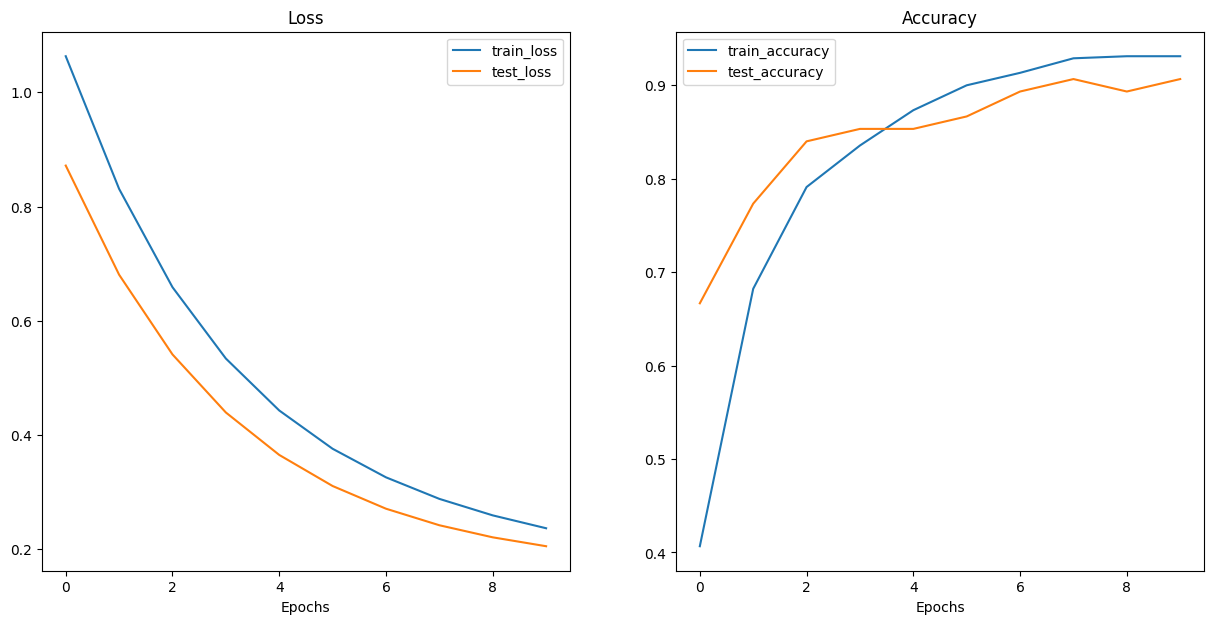

In [36]:
# Examine results
from helper_functions import plot_loss_curves
plot_loss_curves(pretrained_vit_results)

## 4. Try repeating the steps from excercise 3 but this time use the "`ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1`" pretrained weights from [`torchvision.models.vit_b_16()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16).
* Note: ViT pretrained with SWAG weights has a minimum input image size of (384, 384), though this is accessible in the weights `.transforms()` method.

* Note: ViT pretrained with SWAG Weights has a minimum input image size of (384, 384). This is accessible in weights `.transforms()` method.

In [41]:
# Create ViT feature extractor model
import torchvision

# Download pretrained ViT weights and model
vit_weights_swag = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1 # get swag weights
pretrained_vit_swag = torchvision.models.vit_b_16(weights=vit_weights_swag).to(device)

# Freeze all layers in pretrained ViT model
for param in pretrained_vit_swag.parameters():
    param.requires_grad = False

# Update the pretrained ViT head
embedding_dim = 768
pretrained_vit_swag.heads = nn.Sequential(
    nn.LayerNorm(normalized_shape=embedding_dim),
    nn.Linear(
      in_features=embedding_dim,
      out_features=len(class_names))
)

#P Print a summary
summary(model = pretrained_vit_swag,
        input_size= (1, 3, 384, 384),
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 384, 384]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 384, 384]     [1, 768, 24, 24]     (590,592)            False
├─Encoder (encoder)                                          [1, 577, 768]        [1, 577, 768]        443,136              False
│    └─Dropout (dropout)                                     [1, 577, 768]        [1, 577, 768]        --                   --
│    └─Sequential (layers)                                   [1, 577, 768]        [1, 577, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 577, 768]        [1, 577, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 577, 768]        [1, 5

ViT pretrained SWAG weights has a minimum inpu image size of (384, 384), this is accessible through the `.transforms()` method, following the link: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16

In [42]:
# Checlkout transforms for pretrained ViT with Swag Weights
vit_transforms_swag = vit_weights_swag.transforms()
vit_transforms_swag

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [43]:
# Get 20% of data
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

# Setup train and test directories
train_dir_20_percent = data_20_percent_path / "train"
#test_dir_20_percent = data_20_percent_path / "test" don't nered 20% test data as the model in 07. PyTorch Experiment Tracking section 7.3 tests on the 10% of the dataset

# Preprocess the data
train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                          test_dir = test_dir, # use 10% data for testing
                                                                                          transform = vit_transforms_swag,
                                                                                          batch_size = 1024)

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


In [44]:
# Train a pretrained ViT feature extractor with SWAG Weights
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(pretrained_vit_swag.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()
epochs = 10
pretrained_vit_swag_results = engine.train(model = pretrained_vit_swag,
                                      train_dataloader = train_dataloader_20_percent,
                                      test_dataloader = test_dataloader,
                                      optimizer = optimizer,
                                      loss_fn = loss_fn,
                                      epochs = epochs,
                                      device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0160 | train_acc: 0.4867 | test_loss: 0.7546 | test_acc: 0.8533
Epoch: 2 | train_loss: 0.7687 | train_acc: 0.7533 | test_loss: 0.5706 | test_acc: 0.9333
Epoch: 3 | train_loss: 0.5797 | train_acc: 0.8800 | test_loss: 0.4340 | test_acc: 0.9333
Epoch: 4 | train_loss: 0.4398 | train_acc: 0.9422 | test_loss: 0.3340 | test_acc: 0.9600
Epoch: 5 | train_loss: 0.3374 | train_acc: 0.9644 | test_loss: 0.2613 | test_acc: 0.9600
Epoch: 6 | train_loss: 0.2630 | train_acc: 0.9800 | test_loss: 0.2090 | test_acc: 0.9733
Epoch: 7 | train_loss: 0.2091 | train_acc: 0.9778 | test_loss: 0.1715 | test_acc: 0.9733
Epoch: 8 | train_loss: 0.1700 | train_acc: 0.9822 | test_loss: 0.1447 | test_acc: 0.9733
Epoch: 9 | train_loss: 0.1415 | train_acc: 0.9822 | test_loss: 0.1255 | test_acc: 0.9733
Epoch: 10 | train_loss: 0.1205 | train_acc: 0.9822 | test_loss: 0.1115 | test_acc: 0.9733


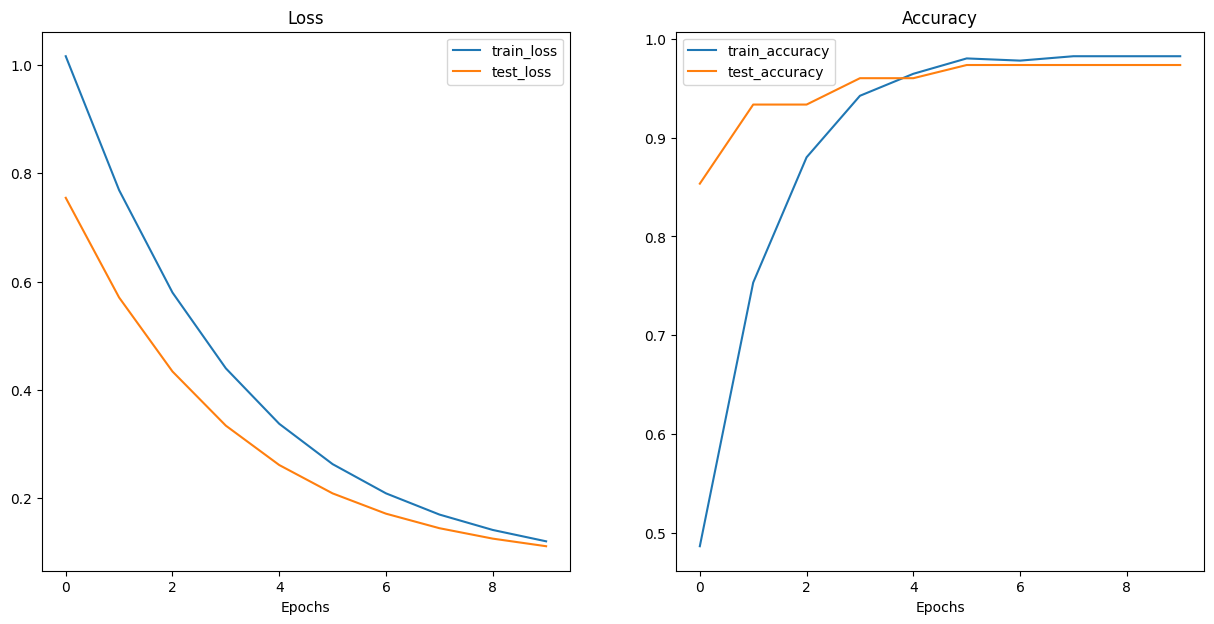

In [45]:
# Examine results
from helper_functions import plot_loss_curves
plot_loss_curves(pretrained_vit_swag_results)

# 5. Our custom ViT model architecture closely mimics that of the ViT paper, however, our training recipe misses a few things.
* Research some of the following topics from Table 3 in the ViT paper that we miss and write a sentence about each and how it might help with training:
    * **ImageNet-21k pretraining**
    * **Learning rate warmup**
    * **Learning rate decay**
    * **Gradient clipping**

In [ ]:
# TODO: your explanations of the above terms